# Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import metrics


# Load Dataset

In [5]:
#read the csv and perform all the numpy and pandas functions
df = pd.read_csv("AI_Impact_on_Jobs_2030.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
print("Null values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


df:                  Job_Title  Average_Salary  Years_Experience Education_Level  \
0          Security Guard           45795                28        Master's   
1      Research Scientist          133355                20             PhD   
2     Construction Worker          146216                 2     High School   
3       Software Engineer          136530                13             PhD   
4       Financial Analyst           70397                22     High School   
...                   ...             ...               ...             ...   
2995               Doctor          111319                 6      Bachelor's   
2996        UX Researcher           44363                29             PhD   
2997       Data Scientist           61325                23        Master's   
2998     Graphic Designer          110296                 7             PhD   
2999     Graphic Designer          123909                25             PhD   

      AI_Exposure_Index  Tech_Growth_Factor  A

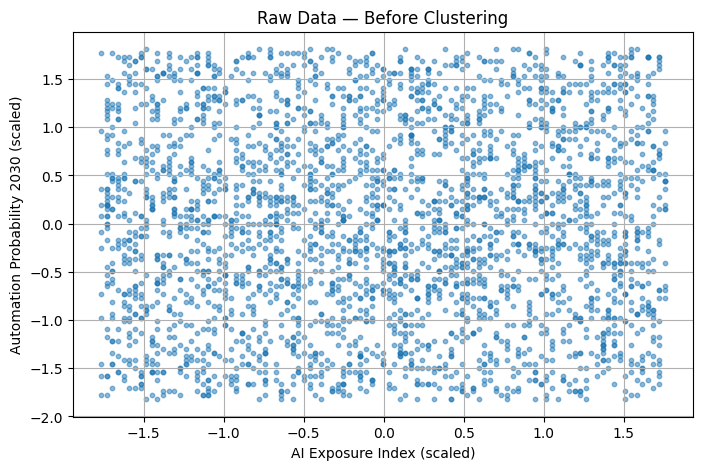

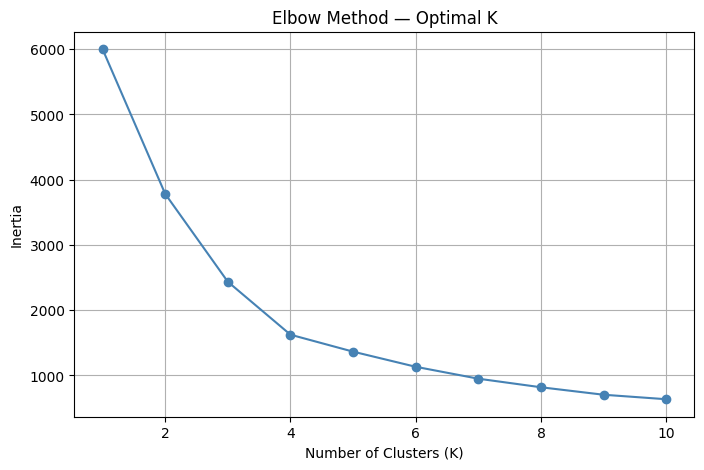

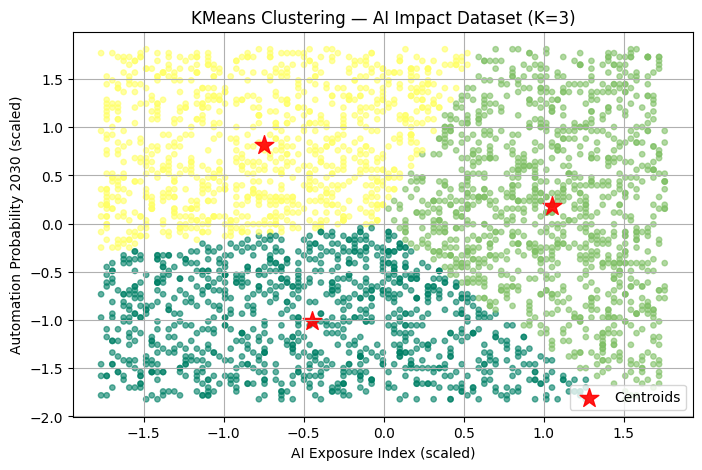

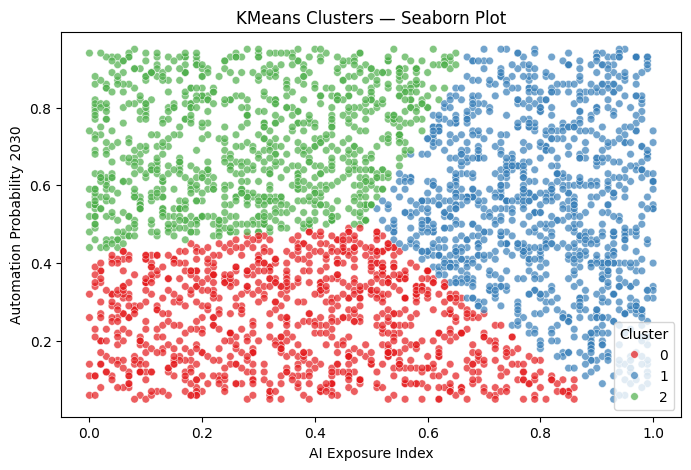

CLUSTERING EVALUATION METRICS
Silhouette Score     : 0.3662
Davies Bouldin Score : 0.8787
Calinski Harabasz    : 2192.7737
Inertia              : 2435.7511


In [ ]:

# CLUSTERING — KMeans on AI Impact on Jobs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Step 1 — Numeric features 
X_cluster = df[['AI_Exposure_Index', 
                'Automation_Probability_2030']].copy()

# Step 2 — Scaleing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Step 3 — Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=10, alpha=0.5)
plt.title("Raw Data — Before Clustering")
plt.xlabel("AI Exposure Index (scaled)")
plt.ylabel("Automation Probability 2030 (scaled)")
plt.grid(True)
plt.show()

# Step 4 — Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title("Elbow Method — Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Step 5 — KMeans 3 clusters (Low/Medium/High)
kmeans = KMeans(n_clusters=3, max_iter=100, random_state=42, n_init=10)
kmeans.fit(X_scaled)
y_kmeans = kmeans.predict(X_scaled)

# Step 6 — Clusters Visulaization
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=y_kmeans, s=15, cmap='summer', alpha=0.6)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            marker='*', c='red', s=200, alpha=0.9,
            label='Centroids')
plt.title("KMeans Clustering — AI Impact Dataset (K=3)")
plt.xlabel("AI Exposure Index (scaled)")
plt.ylabel("Automation Probability 2030 (scaled)")
plt.legend()
plt.grid(True)
plt.show()

# Step 7 — Seaborn scatter plot
df['Cluster'] = y_kmeans

plt.figure(figsize=(8, 5))
sns.scatterplot(x='AI_Exposure_Index',
                y='Automation_Probability_2030',
                hue='Cluster', data=df,
                palette='Set1', s=30, alpha=0.7)
plt.title("KMeans Clusters — Seaborn Plot")
plt.xlabel("AI Exposure Index")
plt.ylabel("Automation Probability 2030")
plt.show()

# Step 8 — Evaluation Metrics
from sklearn import metrics

silhouette = metrics.silhouette_score(X_scaled, y_kmeans)
davies     = metrics.davies_bouldin_score(X_scaled, y_kmeans)
calinski   = metrics.calinski_harabasz_score(X_scaled, y_kmeans)

print("=" * 50)
print("CLUSTERING EVALUATION METRICS")
print("=" * 50)
print(f"Silhouette Score     : {silhouette:.4f}")
print(f"Davies Bouldin Score : {davies:.4f}")
print(f"Calinski Harabasz    : {calinski:.4f}")
print(f"Inertia              : {kmeans.inertia_:.4f}")

# Cleanup
df.drop('Cluster', axis=1, inplace=True)

# Findings

In [ ]:
#KMeans Clustering Analysis

# Used 2 features: AI Exposure Index and Automation Probability 2030
# Applied StandardScaler before clustering
# Used Elbow Method to find the optimal number of clusters (K = 3)
# KMeans successfully grouped the data into 3 clusters

# Cluster Groups

# Cluster 0:Low AI Exposure, Low Automation Risk
# Cluster 1:Medium AI Exposure, Medium Automation Risk
# Cluster 2:High AI Exposure, High Automation Risk

# Performance Metrics

# Silhouette Score:0.37 → Moderate cluster separation
# Davies-Bouldin Score: 0.88 → Acceptable cluster quality
# Calinski-Harabasz Score: 2192.77 → Well-defined clusters
# Inertia: 2435.75 → Stable clustering at K = 3

#Conclusion

# KMeans successfully identified 3 natural groups in the data without using any labels.
# Cluster quality is reasonable, though some overlap exists due to the synthetic nature of the dataset.
